In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import xarray as xr


In [14]:
# Name of shapefile/region
own_region = "manning"

# Shapefile that describes the basin we want to study
path = Path.cwd()
forcing_path = path / "Forcing"
shapeFile = forcing_path / f"{own_region}.shp"

# Location to saved forcing results from previous notebook
forcingLocation = forcing_path / f"{own_region}_1991_2019_Forcing"

#Shape area
shape_area_manning = 6642 * 1000000 # m2

# Load evaporation data from ERA5 #m/day
evap_daily = pd.read_csv("./Data/manning_ERA5_evap_daily.csv")
evap_daily['Date'] = pd.to_datetime(evap_daily['system:index'], format='%Y%m%d')
evap_daily = evap_daily.set_index('Date')[['total_evaporation_sum']].rename(columns={'total_evaporation_sum': 'ERA5_Evaporation'})
# Take absolute value since evaporation is negative in ERA5 data
evap_daily['ERA5_Evaporation'] = evap_daily['ERA5_Evaporation'].abs()

#load precipitation data from ERA5 m/month
precip_daily = pd.read_csv("./Data/manning_ERA5_precip_daily.csv")
precip_daily['Date'] = pd.to_datetime(precip_daily['system:index'], format='%Y%m%d')
precip_daily = precip_daily.set_index('Date')[['total_precipitation_sum']].rename(columns={'total_precipitation_sum': 'ERA5_Precipitation'})      


In [4]:
# Period of interest
experiment_start_time = "1981-01-01T00:00:00Z"
experiment_end_time = "2025-12-31T00:00:00Z"

In [15]:
# fix units of evap and precip data
evap_daily['ERA5_Evaporation'] = evap_daily['ERA5_Evaporation'].abs() * 1000  # Convert m/day to mm/day (already basin-averaged)
precip_daily['ERA5_Precipitation'] = precip_daily['ERA5_Precipitation'] * 1000  # Convert m/day to mm/day (already basin-averaged)

#killawarra station id is 5202080
# Discharge data manning at killawarra station
Obs = pd.read_csv(
    "./Data/5202080_Q_Day.Cmd.txt",
    delimiter=';',
    skiprows=36,
    header=0,
    encoding='cp1252',
    index_col=0,
    parse_dates=True
)
Obs.index.name = 'Day'
Obs = Obs.rename(columns={' Value': 'Q'})  # Note the space before Value
Obs['Q'] = Obs['Q'] * 86400 / shape_area_manning * 1000  # Convert m³/s to mm/day
Obs.loc[Obs['Q'] > 4000, 'Q'] = np.nan
Obs_1 = Obs.loc['1981-01-01':'2025-12-31']
Obs_data = Obs_1['Q'].to_xarray().rename({'Day': 'time'})

In [16]:
precip_xr = precip_daily['ERA5_Precipitation'].to_xarray().rename({'Date': 'time'}).rename('P mm/d')
evap_xr = evap_daily['ERA5_Evaporation'].to_xarray().rename({'Date': 'time'}).rename('EP mm/d')
obs_xr = Obs_data.rename('Q mm/d')

df = xr.merge([precip_xr, evap_xr, obs_xr]).to_dataframe()
data = df[["P mm/d", "EP mm/d", "Q mm/d"]].dropna()
data.index = pd.to_datetime(data.index)

c_pre_deforestation = data.loc["1991-01-01":"1994-12-31"]
c_post_deforestation = data.loc["1996-01-01":"1999-12-31"]
c_pre_deforestation

C:\Users\madis\AppData\Local\Temp\ipykernel_23796\1672104322.py:5: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  df = xr.merge([precip_xr, evap_xr, obs_xr]).to_dataframe()


,P mm/d,EP mm/d,Q mm/d
time,,,
1991-01-01,0.654111,3.679258,0.174439
1991-01-02,0.683483,3.612146,0.162667
1991-01-03,0.001344,3.930138,0.139135
1991-01-04,0.139281,3.451699,0.119597
1991-01-05,22.472925,3.242747,0.099265
...,...,...,...
1994-12-27,0.001297,4.439361,0.025912
1994-12-28,0.003711,4.470221,0.108267
1994-12-29,1.687586,3.544030,0.196046


In [ ]:
si_max = 2.5  # mm
Si1 = 0
Si2 = 0

catchment["Pe_ger"] = 0.0
catchment["Pe_scot"] = 0.0

for i in range(len(catchment)):
    # Germany
    P = catchment["precip1"].iloc[i]
    Ep = catchment["ep1"].iloc[i]

    Si_temp = Si1 + P

    if Si_temp > si_max:
        Pe = Si_temp - si_max
        Si_temp = si_max
    else:
        Pe = 0

    Ei = min(Ep, Si_temp)
    Si1 = Si_temp - Ei

    catchment.loc[catchment.index[i], "Pe_ger"] = Pe

    # Scotland
    P = catchment["precip2"].iloc[i]
    Ep = catchment["ep2"].iloc[i]

    Si_temp = Si2 + P

    if Si_temp > si_max:
        Pe = Si_temp - si_max
        Si_temp = si_max
    else:
        Pe = 0

    Ei = min(Ep, Si_temp)
    Si2 = Si_temp - Ei

    catchment.loc[catchment.index[i], "Pe_scot"] = Pe

In [ ]:
ratio_ger = catchment["Pe_ger"].mean() / catchment["precip1"].mean()
ratio_scot = catchment["Pe_scot"].mean() / catchment["precip2"].mean()

print(f"Germany Pe/P = {ratio_ger:.2f}")
print(f"Scotland Pe/P = {ratio_scot:.2f}")

Germany Pe/P = 0.85
Scotland Pe/P = 0.67


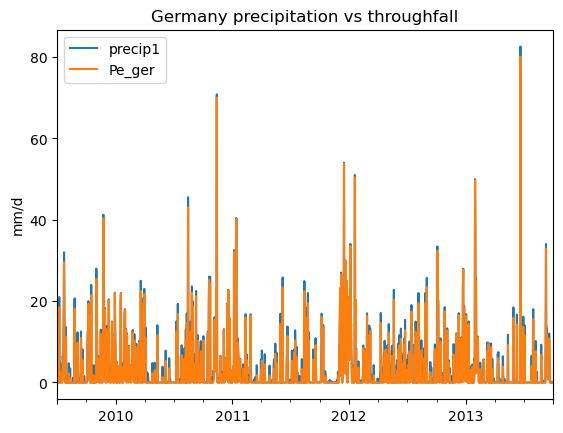

In [ ]:
catchment[["precip1", "Pe_ger"]].plot()
plt.ylabel("mm/d")
plt.title("Germany precipitation vs throughfall")
plt.show()

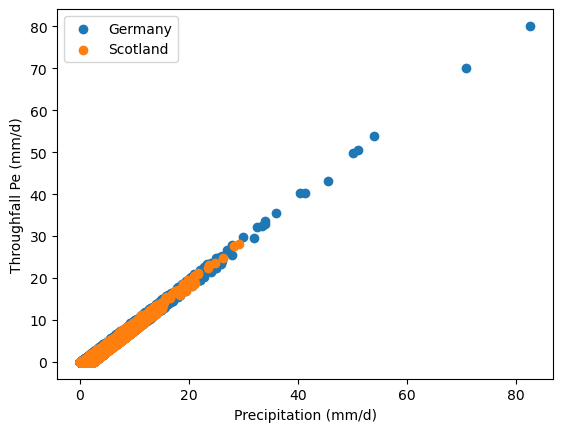

In [ ]:
plt.scatter(catchment["precip1"], catchment["Pe_ger"], label="Germany")
plt.scatter(catchment["precip2"], catchment["Pe_scot"], label="Scotland")

plt.xlabel("Precipitation (mm/d)")
plt.ylabel("Throughfall Pe (mm/d)")
plt.legend()
plt.show()

In [ ]:

file2 = "Rootzone Storage Capacity.xlsx"
rootzone = pd.read_excel(file2, index_col= 0, parse_dates= True, skiprows = 2)
rootzone = rootzone.dropna()

rootzone.columns = ["P_pre", "EP_pre", "Q_pre", "Date_post", "P_post", "EP_post", "Q_post"]

rootzone.head()


,P_pre,EP_pre,Q_pre,Date_post,P_post,EP_post,Q_post
2009-07-01,0.00,4.5268,0.568445,2014-01-01,1.19,0.574843,5.142255
2009-07-02,0.00,5.5186,0.513463,2014-01-02,8.08,0.404378,5.378714
2009-07-03,14.85,0.0598,0.583709,2014-01-03,4.98,0.588081,4.826240
2009-07-04,0.00,4.3604,0.540874,2014-01-04,0.52,0.428248,4.571132
2009-07-05,0.00,2.8604,0.485189,2014-01-05,3.63,0.460895,4.665440


In [ ]:
# pre-deforestation
pre = rootzone[["P_pre", "EP_pre", "Q_pre"]].copy()

# post-deforestation
post = rootzone[["Date_post", "P_post", "EP_post", "Q_post"]].copy()
post = post.dropna()
post["Date_post"] = pd.to_datetime(post["Date_post"])
post = post.set_index("Date_post")
print(pre.head())
print(post.head())


            P_pre  EP_pre     Q_pre
2009-07-01   0.00  4.5268  0.568445
2009-07-02   0.00  5.5186  0.513463
2009-07-03  14.85  0.0598  0.583709
2009-07-04   0.00  4.3604  0.540874
2009-07-05   0.00  2.8604  0.485189
            P_post   EP_post    Q_post
Date_post                             
2014-01-01    1.19  0.574843  5.142255
2014-01-02    8.08  0.404378  5.378714
2014-01-03    4.98  0.588081  4.826240
2014-01-04    0.52  0.428248  4.571132
2014-01-05    3.63  0.460895  4.665440


In [ ]:
pre["ET"] = pre["P_pre"] - pre["Q_pre"]
post["ET"] = post["P_post"] - post["Q_post"]
pre["ET"] = pre["ET"].clip(lower=0)
post["ET"] = post["ET"].clip(lower=0)

In [ ]:

# 1) Long-term mean ET from the water balance
ET_mean_pre = pre["P_pre"].mean() - pre["Q_pre"].mean()
ET_mean_post = post["P_post"].mean() - post["Q_post"].mean()

# 2) Scale daily ET with daily EP
pre["ET_daily"] = (pre["EP_pre"] / pre["EP_pre"].mean()) * ET_mean_pre
post["ET_daily"] = (post["EP_post"] / post["EP_post"].mean()) * ET_mean_post

# 3) Compute storage deficit for pre-deforestation period
sd_pre = [0.0]

for i in range(1, len(pre)):
    new_sd = min(0, sd_pre[i-1] + pre["P_pre"].iloc[i] - pre["ET_daily"].iloc[i])
    sd_pre.append(new_sd)

pre["SD"] = sd_pre

# 4) Compute storage deficit for post-deforestation period
sd_post = [0.0]

for i in range(1, len(post)):
    new_sd = min(0, sd_post[i-1] + post["P_post"].iloc[i] - post["ET_daily"].iloc[i])
    sd_post.append(new_sd)

post["SD"] = sd_post

# 5) Root-zone storage capacity = maximum storage deficit
SR_pre = (-pre["SD"]).max()
SR_post = (-post["SD"]).max()

print("SR pre-deforestation =", SR_pre, "mm")
print("SR post-deforestation =", SR_post, "mm")

SR pre-deforestation = 211.69777288464422 mm
SR post-deforestation = 47.18707681619864 mm


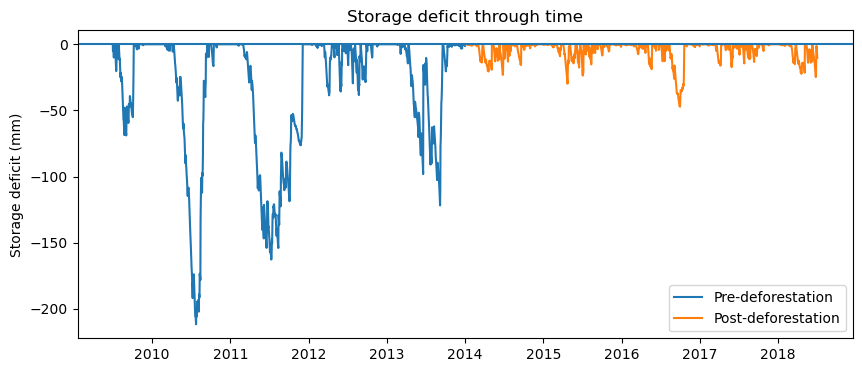

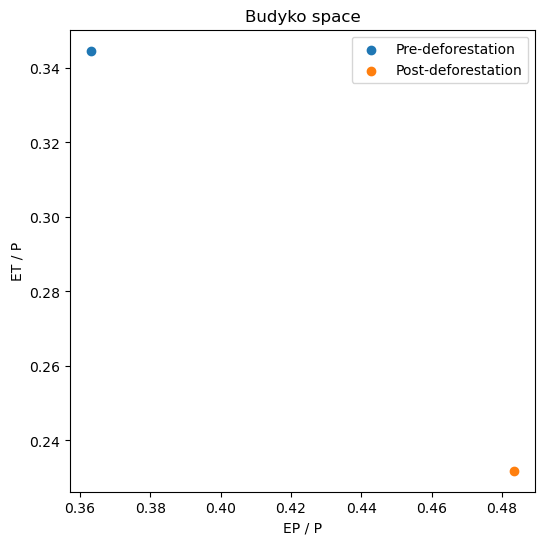

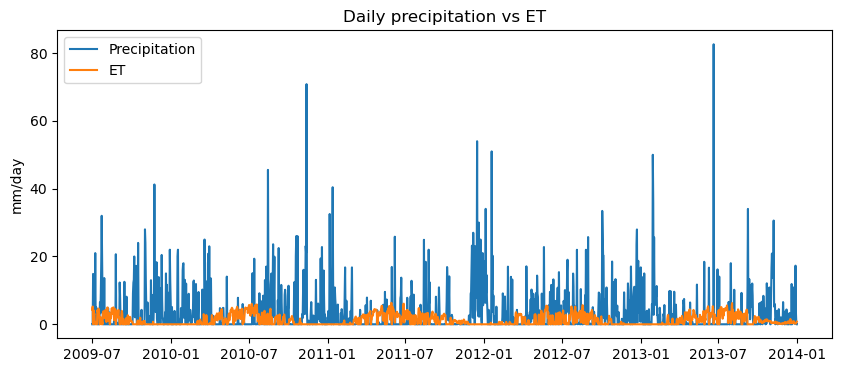

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(pre["SD"], label="Pre-deforestation")
plt.plot(post["SD"], label="Post-deforestation")

plt.axhline(0)
plt.ylabel("Storage deficit (mm)")
plt.title("Storage deficit through time")
plt.legend()


x_pre = pre["EP_pre"].mean() / pre["P_pre"].mean()
y_pre = ET_mean_pre / pre["P_pre"].mean()

x_post = post["EP_post"].mean() / post["P_post"].mean()
y_post = ET_mean_post / post["P_post"].mean()

plt.figure(figsize=(6,6))
plt.scatter(x_pre, y_pre, label="Pre-deforestation")
plt.scatter(x_post, y_post, label="Post-deforestation")

plt.xlabel("EP / P")
plt.ylabel("ET / P")
plt.title("Budyko space")
plt.legend()


plt.figure(figsize=(10,4))
plt.plot(pre["P_pre"], label="Precipitation")
plt.plot(pre["ET_daily"], label="ET")

plt.ylabel("mm/day")
plt.title("Daily precipitation vs ET")
plt.legend()